# Benchmark — Music Emotion Recognition (DEAM)
#### Comparação dos modelos dinâmicos: **ResNet18 × {STFT, Mel, MFCC}**

Este notebook compara três representações espectrais de áudio — **Mel Espectrograma**, **STFT** e **MFCC** — como entrada para uma mesma rede neural (ResNet18) treinada para prever as dimensões emocionais **Arousal** (energia/excitação) e **Valence** (positividade) em músicas do dataset DEAM.

Todos os modelos foram treinados com os **mesmos hiperparâmetros**, mesma divisão de dados e mesma arquitetura, garantindo que as diferenças de desempenho reflitam apenas a qualidade de cada representação espectral.

In [14]:
import json, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
cores_modo = {'MEL': '#2196F3', 'STFT': '#4CAF50', 'MFCC': '#FF5722'}

resultados = {}
for path in sorted(glob.glob('resultados_*_dinamico.json')):
    if 'chroma' in path:
        continue
    with open(path) as f:
        resultados.update(json.load(f))

print(f'Experimentos carregados: {len(resultados)}')
for k in resultados: print(f'  {k}')


Experimentos carregados: 3
  resnet18_mel_dinamico
  resnet18_mfcc_dinamico
  resnet18_stft_dinamico


,Modo,Pearson A,Pearson V,CCC A,CCC V,RMSE A,RMSE V,Acuracia Q,F1-macro Q,Tempo (min),GPU Pico (MB)
0,STFT,0.7781,0.5047,0.7701,0.5036,0.0840,0.1047,0.5876,0.4574,71.1000,1107.9000
1,MEL,0.7615,0.5031,0.7565,0.4987,0.0941,0.1041,0.5946,0.4538,45.8000,1101.3000
2,MFCC,0.6950,0.4706,0.6899,0.4607,0.1027,0.1058,0.5427,0.4440,14.5000,727.4000


C:\Users\USUARIOS\AppData\Local\Temp\ipykernel_19720\2430572633.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_good = plt.cm.get_cmap('RdYlGn')


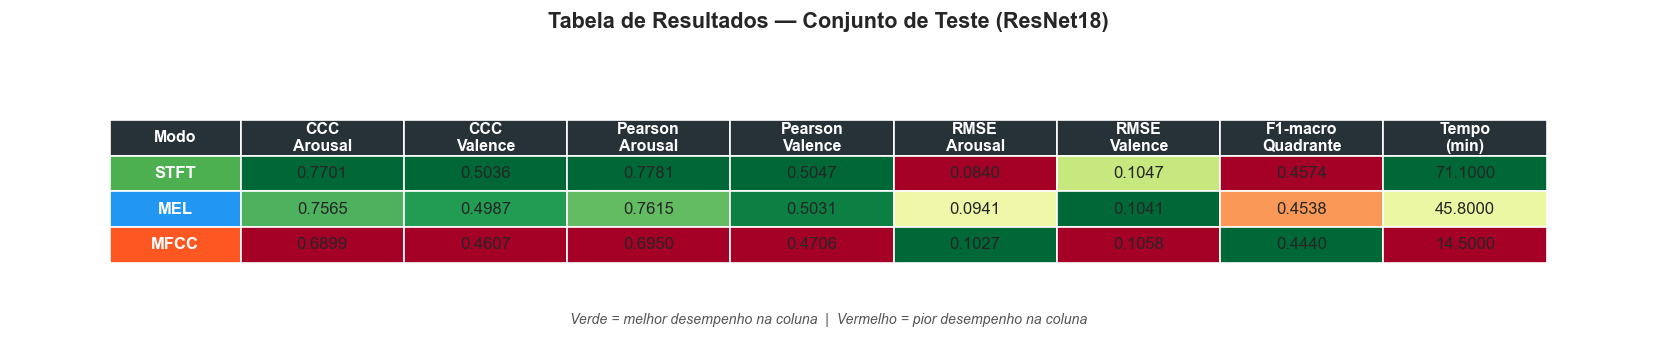

Salvo em: figuras_tcc/tabela_resultados_5_1.png


In [15]:
import os
import matplotlib.colors as mcolors

rows = []
for nome, r in resultados.items():
    modo = nome.split('_')[1].upper()
    rows.append({'Modo': modo,
        'Pearson A': r['test_pearson_arousal'], 'Pearson V': r['test_pearson_valence'],
        'CCC A': r['test_ccc_arousal'],         'CCC V': r['test_ccc_valence'],
        'RMSE A': r['test_rmse_arousal'],        'RMSE V': r['test_rmse_valence'],
        'MAE A': r['test_mae_arousal'],          'MAE V': r['test_mae_valence'],
        'R2 A': r['test_r2_arousal'],            'R2 V': r['test_r2_valence'],
        'Acuracia Q': r['quadrant_accuracy'],    'F1-macro Q': r['quadrant_f1_macro'],
        'Tempo (min)': round(r['tempo_total_seg']/60, 1),
        'GPU Pico (MB)': r['gpu_mem_pico_mb']})

df = pd.DataFrame(rows).sort_values('Pearson A', ascending=False).reset_index(drop=True)

# ── Tabela interativa no notebook ───────────────────────────────────────────
cols = ['Modo','Pearson A','Pearson V','CCC A','CCC V','RMSE A','RMSE V','Acuracia Q','F1-macro Q','Tempo (min)','GPU Pico (MB)']
display(df[cols].style
    .background_gradient(subset=['Pearson A','Pearson V','CCC A','CCC V','Acuracia Q','F1-macro Q'], cmap='Greens')
    .background_gradient(subset=['RMSE A','RMSE V','Tempo (min)','GPU Pico (MB)'], cmap='Reds_r')
    .format(precision=4))

# ── Figura exportável para o TCC ────────────────────────────────────────────
COLS_TCC  = ['Modo', 'CCC A', 'CCC V', 'Pearson A', 'Pearson V', 'RMSE A', 'RMSE V', 'F1-macro Q', 'Tempo (min)']
HEADERS   = ['Modo', 'CCC\nArousal', 'CCC\nValence', 'Pearson\nArousal', 'Pearson\nValence',
             'RMSE\nArousal', 'RMSE\nValence', 'F1-macro\nQuadrante', 'Tempo\n(min)']
CORES_MOD = {'STFT': '#4CAF50', 'MEL': '#2196F3', 'MFCC': '#FF5722'}

# Normalização por coluna para cor de fundo (verde = bom, vermelho = ruim)
def norm_col(vals, reverse=False):
    mn, mx = min(vals), max(vals)
    if mx == mn: return [0.5]*len(vals)
    n = [(v - mn)/(mx - mn) for v in vals]
    return [1-x for x in n] if reverse else n

data_tcc = df[COLS_TCC].copy()
n_rows, n_cols = len(data_tcc), len(COLS_TCC)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis('off')

col_widths = [0.08] + [0.10]*(n_cols-1)
table = ax.table(
    cellText=[[f'{v:.4f}' if isinstance(v, float) else str(v)
               for v in row] for row in data_tcc.values],
    colLabels=HEADERS,
    cellLoc='center', loc='center',
    colWidths=col_widths
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Estilo do cabeçalho
for j in range(n_cols):
    cell = table[0, j]
    cell.set_facecolor('#263238')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9.5)
    cell.set_edgecolor('#ffffff')

# Cor de fundo das linhas de dados
metric_cols_idx = list(range(1, n_cols))
reverse_cols    = {6: True, 7: True}   # RMSE A, RMSE V (menor = melhor)

col_norms = {}
for ci in metric_cols_idx:
    vals = [float(data_tcc.iloc[ri, ci]) for ri in range(n_rows)]
    col_norms[ci] = norm_col(vals, reverse=ci in reverse_cols)

cmap_good = plt.cm.get_cmap('RdYlGn')

for ri in range(n_rows):
    modo = data_tcc.iloc[ri, 0]
    # Coluna Modo — cor do modo
    cell = table[ri+1, 0]
    cell.set_facecolor(CORES_MOD.get(modo, '#eeeeee'))
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#ffffff')

    for ci in metric_cols_idx:
        cell = table[ri+1, ci]
        rgba = cmap_good(col_norms[ci][ri])
        cell.set_facecolor(rgba)
        cell.set_text_props(fontsize=10)
        cell.set_edgecolor('#ffffff')

fig.suptitle('Tabela de Resultados — Conjunto de Teste (ResNet18)',
             fontsize=13, fontweight='bold', y=1.02)

ax.text(0.5, -0.08,
        'Verde = melhor desempenho na coluna  |  Vermelho = pior desempenho na coluna',
        ha='center', va='top', transform=ax.transAxes,
        fontsize=8.5, color='#555555', style='italic')

plt.tight_layout()
os.makedirs('figuras_tcc', exist_ok=True)
plt.savefig('figuras_tcc/tabela_resultados_5_1.png', dpi=200, bbox_inches='tight')
plt.show()
print("Salvo em: figuras_tcc/tabela_resultados_5_1.png")


## 1. Correlação de Pearson — Arousal & Valence

A **Correlação de Pearson** mede o quanto as predições do modelo acompanham a direção e tendência dos valores reais, em uma escala de -1 (inverso perfeito) a 1 (perfeito). 

- Valores acima de **0.70** são considerados bons em tarefas de MER na literatura
- **Arousal** (energia da música) tende a ser mais fácil de prever que **Valence** (positividade), pois tem correlação mais clara com características acústicas como volume e ritmo
- A linha tracejada vermelha marca o limiar de referência 0.70

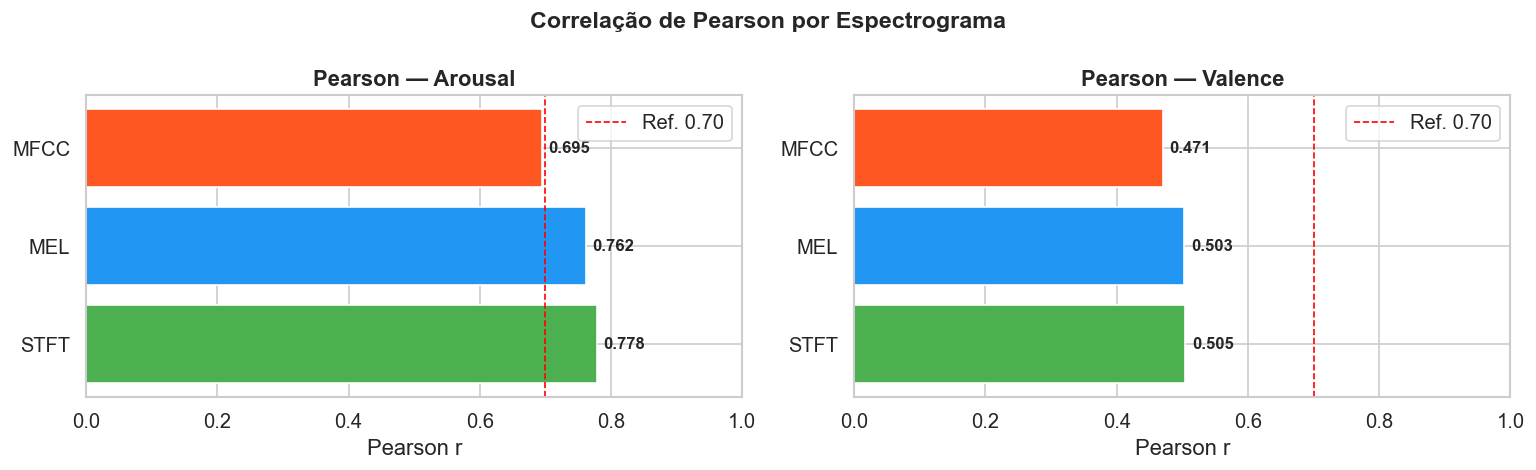

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, titulo in zip(axes, ['Pearson A','Pearson V'], ['Arousal','Valence']):
    cores = [cores_modo[m] for m in df['Modo']]
    bars  = ax.barh(df['Modo'], df[col], color=cores, edgecolor='white')
    ax.axvline(0.7, color='red', linestyle='--', linewidth=1, label='Ref. 0.70')
    ax.set_xlabel('Pearson r'); ax.set_title(f'Pearson — {titulo}', fontweight='bold'); ax.set_xlim(0, 1)
    for bar, v in zip(bars, df[col]):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.legend()
plt.suptitle('Correlação de Pearson por Espectrograma', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 2. CCC — Concordance Correlation Coefficient

O **CCC (Coeficiente de Correlação de Concordância)** é a métrica principal utilizada na literatura de MER. Ele é mais rigoroso que o Pearson porque penaliza predições que acertam a direção mas erram a escala ou o nível médio — ou seja, o modelo precisa prever não só "subiu/desceu" mas também o valor absoluto correto.

- Fórmula: combina Pearson com a diferença entre as médias e variâncias de predição e ground truth
- Valores acima de **0.65** são considerados competitivos em MER com anotações dinâmicas
- A linha tracejada marca o limiar de referência 0.65

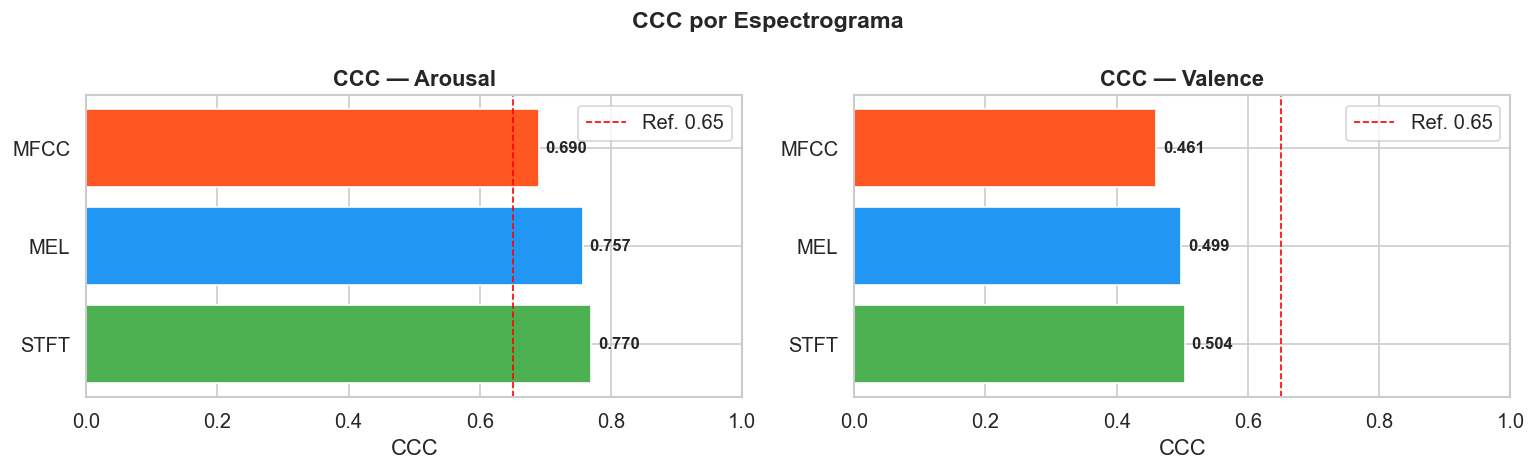

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, titulo in zip(axes, ['CCC A','CCC V'], ['Arousal','Valence']):
    cores = [cores_modo[m] for m in df['Modo']]
    bars  = ax.barh(df['Modo'], df[col], color=cores, edgecolor='white')
    ax.axvline(0.65, color='red', linestyle='--', linewidth=1, label='Ref. 0.65')
    ax.set_xlabel('CCC'); ax.set_title(f'CCC — {titulo}', fontweight='bold'); ax.set_xlim(0, 1)
    for bar, v in zip(bars, df[col]):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.legend()
plt.suptitle('CCC por Espectrograma', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 3. Comparação Geral: MEL vs STFT vs MFCC

Visão lado a lado de todas as métricas principais para os três espectrogramas. Cada barra representa o desempenho no conjunto de teste final (músicas que o modelo nunca viu durante o treino).

- **Pearson / CCC**: quanto maior, melhor — o modelo acerta mais a trajetória emocional da música
- **RMSE / MAE**: quanto menor, melhor — menor erro absoluto nas predições de arousal e valence
- O **RMSE** penaliza erros grandes mais severamente que o MAE, sendo mais sensível a predições muito erradas

In [ ]:
import os
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

MODOS_ORDEM = ['STFT', 'MEL', 'MFCC']
sub    = df.set_index('Modo')
cores  = {'STFT': '#4CAF50', 'MEL': '#2196F3', 'MFCC': '#FF5722'}
height = 0.22   # espessura das barras

metricas_fig = [
    ('CCC A',     'CCC V',     'CCC — Arousal / Valence',     0.65, 'CCC'),
    ('Pearson A', 'Pearson V', 'Pearson — Arousal / Valence', 0.70, 'Pearson r'),
    ('RMSE A',    'RMSE V',    'RMSE — Arousal / Valence',    None, 'RMSE'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(
    'Desempenho por Representação Espectral — Conjunto de Teste',
    fontsize=14, fontweight='bold', y=1.03
)

y = np.arange(len(MODOS_ORDEM))

for ax, (col_a, col_v, titulo, ref, xlabel) in zip(axes, metricas_fig):
    vals_a = [sub.loc[m, col_a] for m in MODOS_ORDEM]
    vals_v = [sub.loc[m, col_v] for m in MODOS_ORDEM]
    c_list = [cores[m] for m in MODOS_ORDEM]

    bars_a = ax.barh(y + height/2, vals_a, height, color=c_list,
                     edgecolor='white', linewidth=1.1, alpha=1.0)
    bars_v = ax.barh(y - height/2, vals_v, height, color=c_list,
                     edgecolor='white', linewidth=1.1, alpha=0.45, hatch='//')

    # Rótulos de valor
    for bar, v in zip(bars_a, vals_a):
        ax.text(v + 0.006, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='left', fontsize=8.5, fontweight='bold')
    for bar, v in zip(bars_v, vals_v):
        ax.text(v + 0.006, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', ha='left', fontsize=8.5, color='#555')

    if ref:
        ax.axvline(ref, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

    ax.set_yticks(y)
    ax.set_yticklabels(MODOS_ORDEM, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    x_max = max(vals_a + vals_v)
    ax.set_xlim(0, min(1.0, x_max * 1.25))
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    Patch(facecolor=cores['STFT'], label='STFT'),
    Patch(facecolor=cores['MEL'],  label='MEL'),
    Patch(facecolor=cores['MFCC'], label='MFCC'),
    Patch(facecolor='white', edgecolor='black', label='Arousal (sólido)'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Valence (hachura)'),
    Line2D([0],[0], color='red', linestyle='--', linewidth=1.5, label='Limiar referência'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.10), frameon=True)

plt.tight_layout()
os.makedirs('figuras_tcc', exist_ok=True)
plt.savefig('figuras_tcc/fig_desempenho_5_1.png', dpi=200, bbox_inches='tight')
plt.show()
print("Salvo em: figuras_tcc/fig_desempenho_5_1.png")

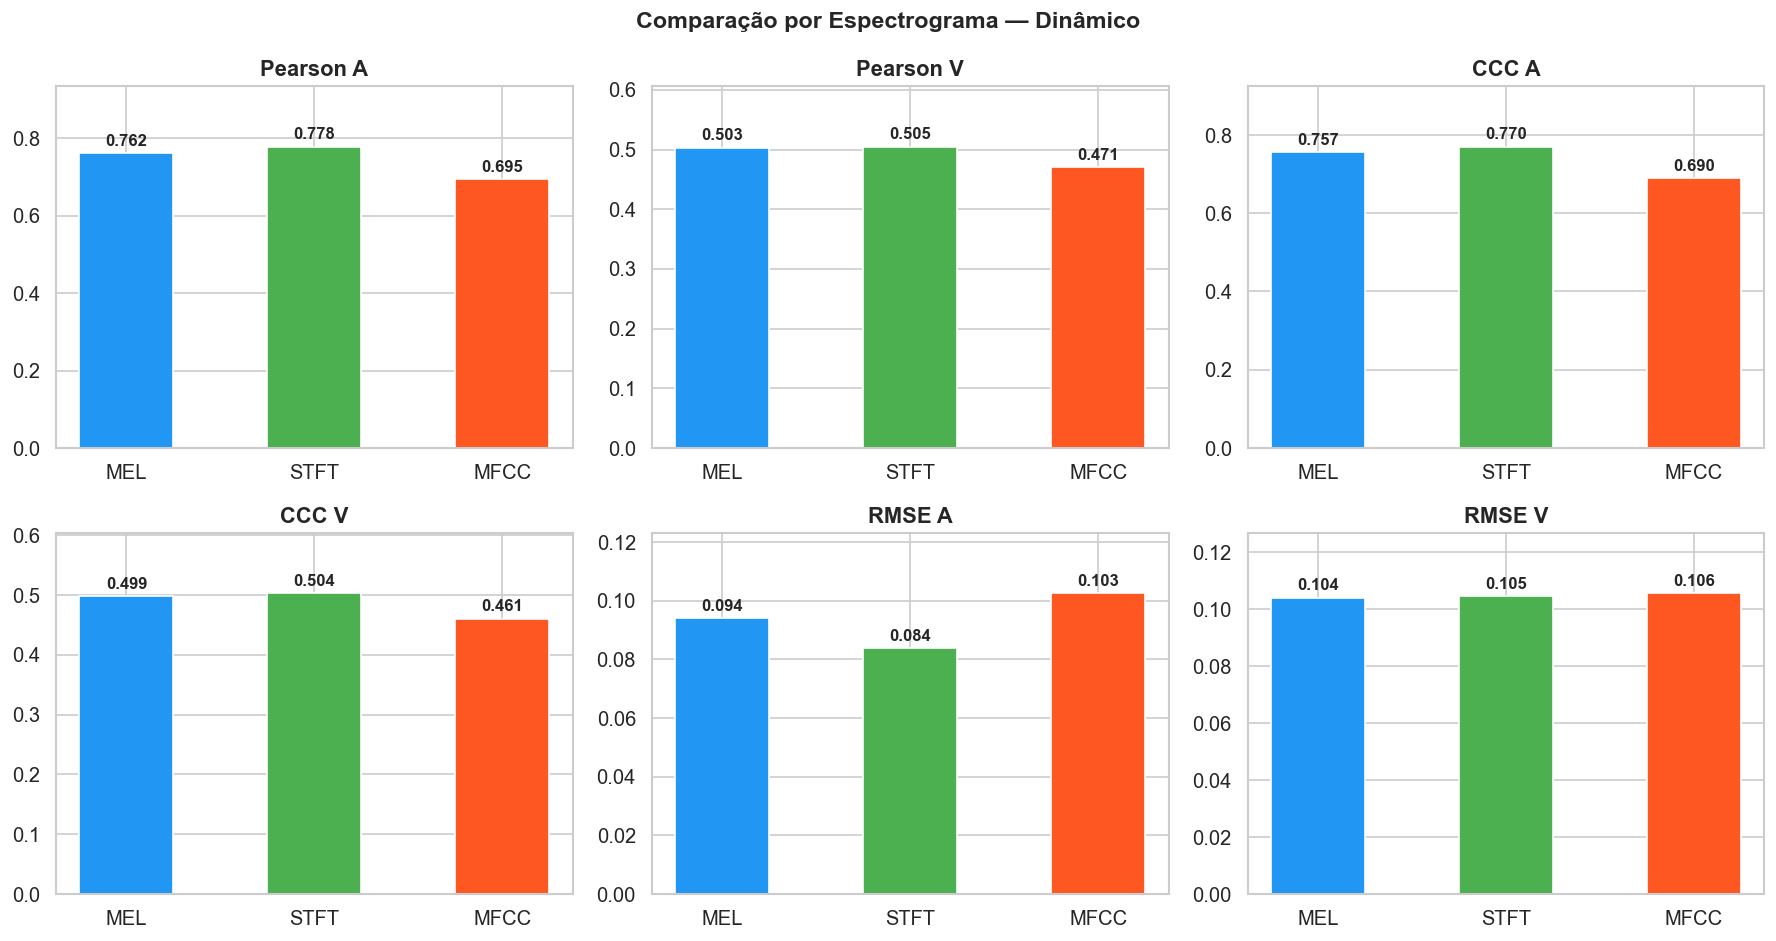

In [19]:
metricas = ['Pearson A','Pearson V','CCC A','CCC V','RMSE A','RMSE V']
modos    = ['MEL','STFT','MFCC']
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.flatten()
sub = df.set_index('Modo')
for ax, metrica in zip(axes, metricas):
    vals  = [sub.loc[m, metrica] if m in sub.index else 0 for m in modos]
    cores = [cores_modo[m] for m in modos]
    bars  = ax.bar(modos, vals, color=cores, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    lim = max(vals)*1.2 if max(vals)>0 else 1; ax.set_ylim(0, lim)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+lim*0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Comparação por Espectrograma — Dinâmico', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Radar Chart — Visão Holística

O gráfico radar permite comparar todos os modelos em múltiplas dimensões de uma vez. Cada vértice representa uma métrica diferente, e a área preenchida representa o desempenho geral de cada representação espectral.

- Um modelo ideal teria a área preenchida cobrindo o máximo do hexágono em todos os vértices
- Assimetrias no formato revelam pontos fracos específicos: ex., bom em Arousal mas fraco em Valence
- Útil para identificar qual representação tem o perfil mais **equilibrado** entre as métricas

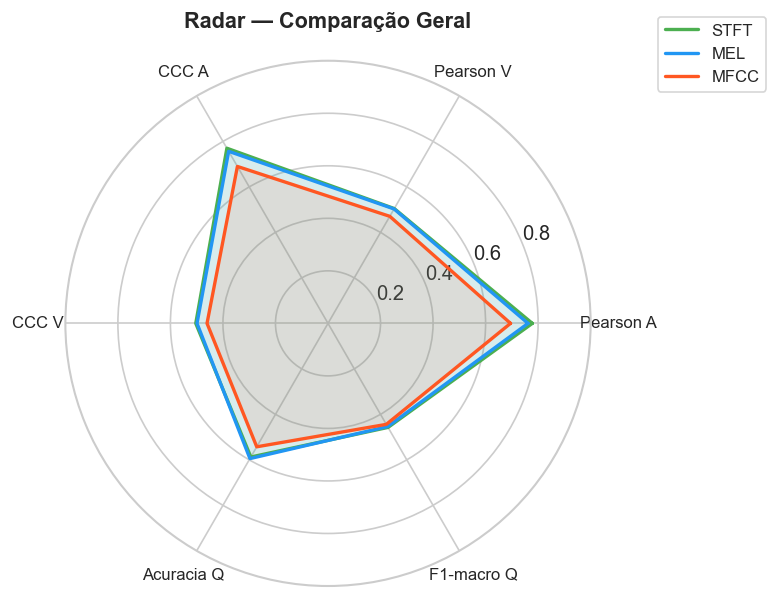

In [20]:
cats   = ['Pearson A','Pearson V','CCC A','CCC V','Acuracia Q','F1-macro Q']
N      = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for _, row in df.iterrows():
    vals = [row[c] for c in cats] + [row[cats[0]]]
    cor  = cores_modo[row['Modo']]
    ax.plot(angles, vals, linewidth=2, label=row['Modo'], color=cor)
    ax.fill(angles, vals, alpha=0.1, color=cor)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticks([0.2,0.4,0.6,0.8])
ax.set_title('Radar — Comparação Geral', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1), fontsize=10)
plt.tight_layout(); plt.show()


## 5. Curvas de Aprendizado (melhor fold de cada modelo)

Mostra como cada modelo evoluiu durante o treino época por época — especificamente no melhor fold do 5-fold cross-validation. Permite identificar padrões como:

- **Convergência rápida vs lenta**: MFCC converge mais rápido pois tem menos informação espectral
- **Overfitting**: gap crescente entre train loss e val loss indica que o modelo memorizou o treino
- **Plateau**: métricas que param de crescer indicam o ponto onde o early stopping atuou
- A linha sólida é o treino; a tracejada é a validação — idealmente devem convergir próximas

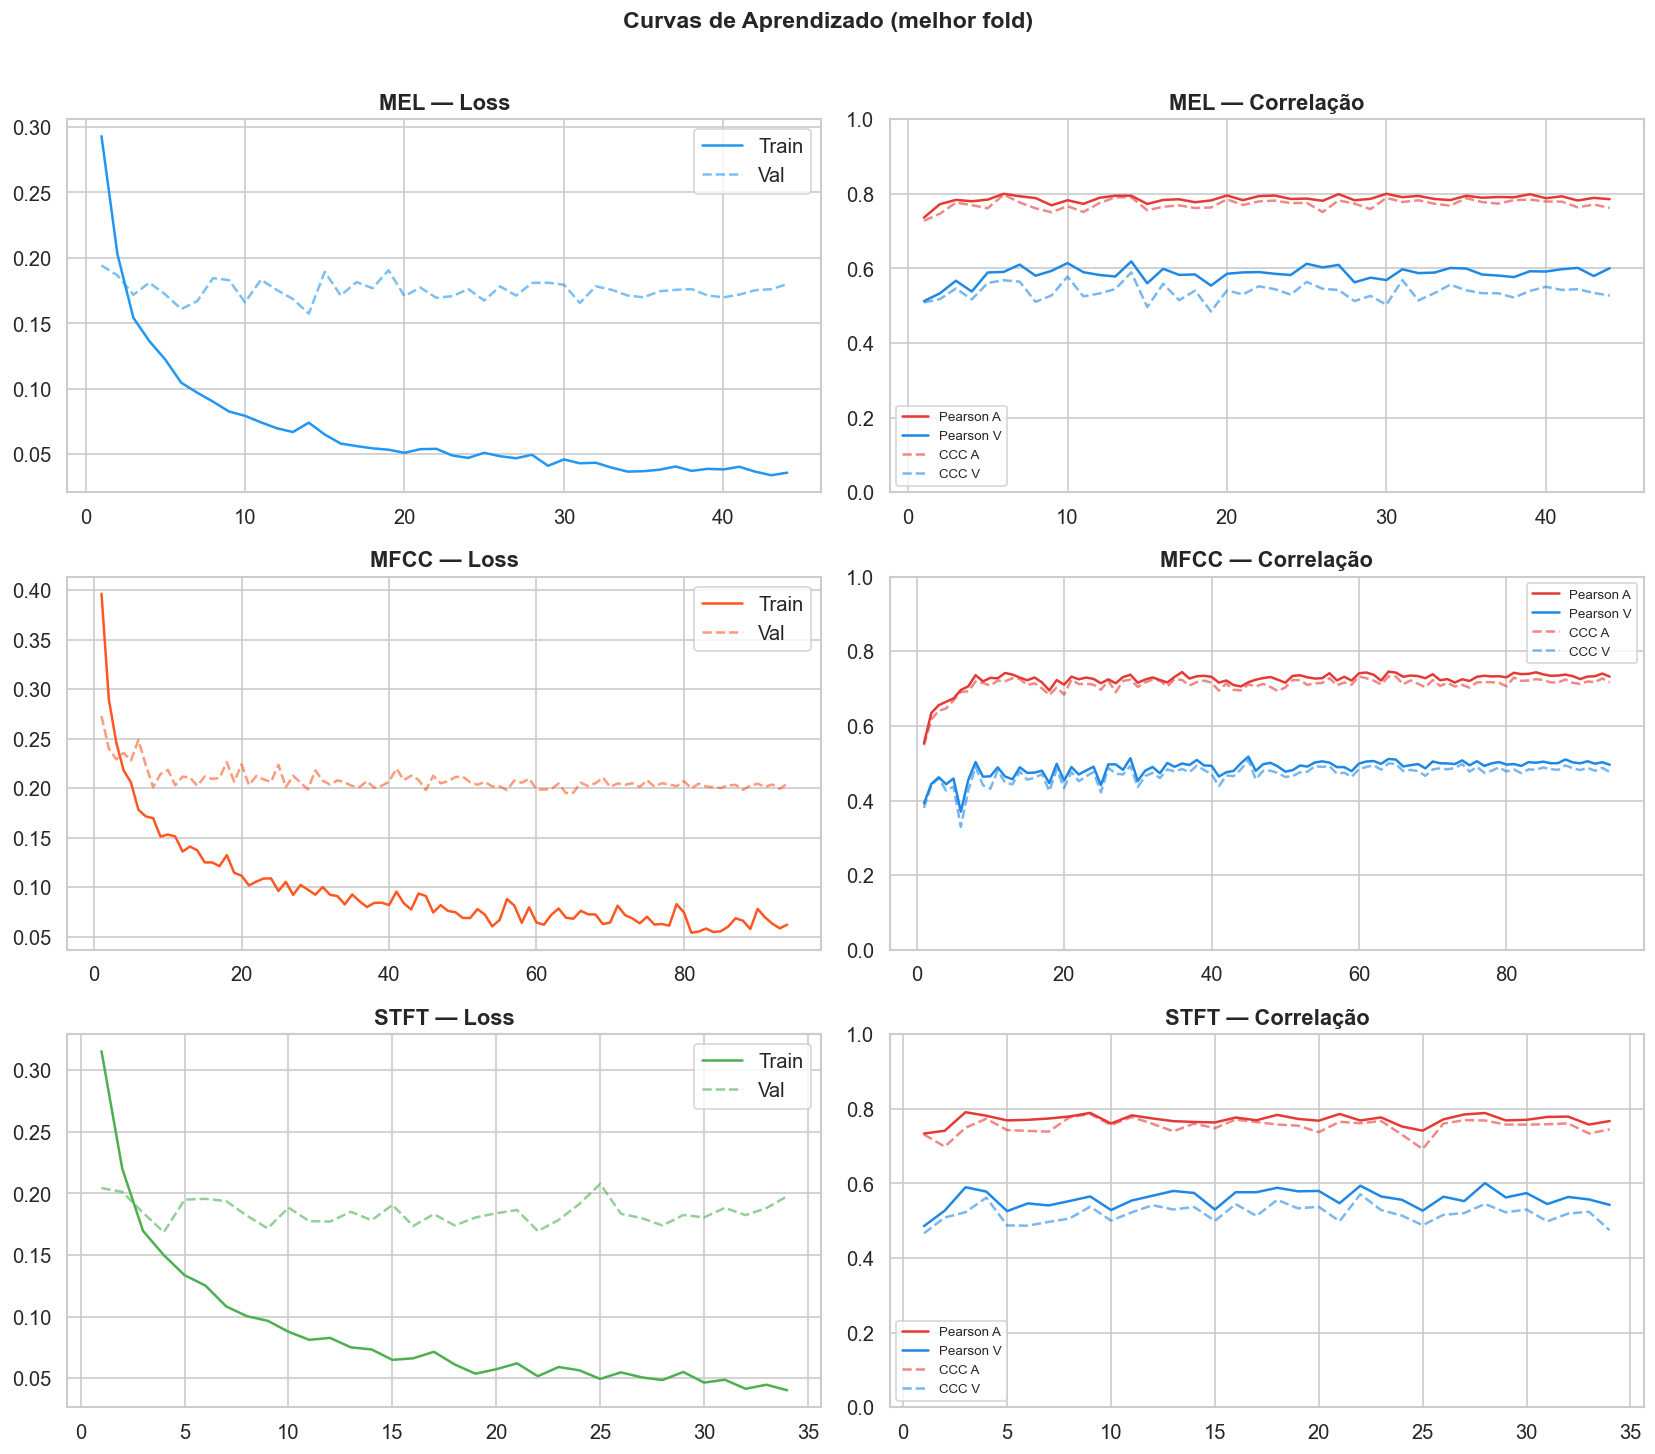

In [21]:
n_exp = len(resultados)
fig, axes = plt.subplots(n_exp, 2, figsize=(14, 4*n_exp))
if n_exp == 1: axes = [axes]
for i, (nome, r) in enumerate(resultados.items()):
    if not r.get('epocas'):
        for j in range(2): axes[i][j].text(0.5,0.5,'Sem dados de epoca',ha='center',va='center',transform=axes[i][j].transAxes)
        continue
    ep = r['epocas']
    ep_n = [e['epoca'] for e in ep]; tl = [e['train_loss'] for e in ep]; vl = [e['val_loss'] for e in ep]
    pa = [e['pearson_arousal'] for e in ep]; pv = [e['pearson_valence'] for e in ep]
    ca = [e['ccc_arousal'] for e in ep];     cv = [e['ccc_valence'] for e in ep]
    modo = nome.split('_')[1].upper(); cor = cores_modo.get(modo,'#555')
    axes[i][0].plot(ep_n, tl, label='Train', color=cor)
    axes[i][0].plot(ep_n, vl, label='Val', color=cor, linestyle='--', alpha=0.6)
    axes[i][0].set_title(f'{modo} — Loss', fontweight='bold'); axes[i][0].legend()
    axes[i][1].plot(ep_n, pa, label='Pearson A', color='#E53935')
    axes[i][1].plot(ep_n, pv, label='Pearson V', color='#1E88E5')
    axes[i][1].plot(ep_n, ca, label='CCC A', color='#E53935', linestyle='--', alpha=0.6)
    axes[i][1].plot(ep_n, cv, label='CCC V', color='#1E88E5', linestyle='--', alpha=0.6)
    axes[i][1].set_title(f'{modo} — Correlação', fontweight='bold'); axes[i][1].set_ylim(0,1); axes[i][1].legend(fontsize=8)
plt.suptitle('Curvas de Aprendizado (melhor fold)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 6. Desempenho por Quadrante Emocional (Russell Circumplex)

As emoções foram classificadas em 4 quadrantes do modelo de Russell (1980), que organiza emoções em dois eixos: Arousal (energia) e Valence (positividade):

| Quadrante | Arousal | Valence | Exemplos |
|---|---|---|---|
| **Exaltado** | Alto | Alto | Feliz, animado, eufórico |
| **Irritado** | Alto | Baixo | Tenso, agressivo, agitado |
| **Calmo** | Baixo | Alto | Sereno, relaxado, suave |
| **Triste** | Baixo | Baixo | Melancólico, deprimido |

O heatmap mostra Precisão, Recall e F1 por quadrante. Quadrantes com poucos exemplos no dataset (Calmo, Irritado) tendem a ter pior desempenho — problema de desbalanceamento tratado com WeightedRandomSampler e Mixup durante o treino.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

QUADRANTES = ['Exaltado (A+V+)', 'Irritado (A+V-)', 'Calmo (A-V+)', 'Triste (A-V-)']
LABELS_Q   = ['Exaltado\n↑ Arousal  ↑ Valence',
               'Irritado\n↑ Arousal  ↓ Valence',
               'Calmo\n↓ Arousal  ↑ Valence',
               'Triste\n↓ Arousal  ↓ Valence']
METRICAS   = ['Precisão', 'Recall', 'F1-score']
CORES_MOD  = {'MEL': '#2196F3', 'STFT': '#4CAF50', 'MFCC': '#FF5722'}
ORDEM      = ['STFT', 'MEL', 'MFCC']

dados_q = {}
for nome, r in resultados.items():
    modo    = nome.split('_')[1].upper()
    rep     = r['quadrant_report']
    nomes_q = [q for q in QUADRANTES if q in rep]
    mat     = np.array([[rep[q]['precision'], rep[q]['recall'], rep[q]['f1-score']]
                        for q in nomes_q])
    dados_q[modo] = {'mat': mat, 'acc': r['quadrant_accuracy'], 'f1': r['quadrant_f1_macro']}

cmap = plt.cm.YlGn
norm = mcolors.Normalize(vmin=0, vmax=1)

os.makedirs('figuras_tcc', exist_ok=True)

for modo in ORDEM:
    d   = dados_q[modo]
    mat = d['mat'].T
    n_m, n_q = mat.shape

    fig, ax = plt.subplots(figsize=(14, 3.8))

    ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')

    for i in range(n_m + 1):
        ax.axhline(i - 0.5, color='white', linewidth=3)
    for j in range(n_q + 1):
        ax.axvline(j - 0.5, color='white', linewidth=3)
    ax.axhline(n_m - 1 - 0.5, color='white', linewidth=6)

    for ri in range(n_m):
        for ci in range(n_q):
            val    = mat[ri, ci]
            tc     = 'white' if val > 0.60 else '#1a1a1a'
            weight = 'bold'  if ri == n_m - 1 else 'normal'
            size   = 16      if ri == n_m - 1 else 14
            ax.text(ci, ri, f'{val:.2f}', ha='center', va='center',
                    fontsize=size, color=tc, fontweight=weight)

    ax.set_xticks(range(n_q))
    ax.set_xticklabels(LABELS_Q, fontsize=12, ha='center', linespacing=1.55)
    ax.xaxis.set_ticks_position('bottom')

    ax.set_yticks(range(n_m))
    ax.set_yticklabels(METRICAS, fontsize=13, fontweight='bold')
    ax.tick_params(length=0, pad=10)

    for spine in ax.spines.values():
        spine.set_visible(False)

    cor = CORES_MOD[modo]
    ax.set_title(
        f'{modo}  —  Acurácia: {d["acc"]:.3f}   F1-macro: {d["f1"]:.3f}',
        fontsize=14, fontweight='bold', color='white', pad=13,
        bbox=dict(boxstyle='round,pad=0.55', facecolor=cor, edgecolor='none')
    )

    fig.text(0.5, -0.06,
             'F1-score (negrito, última linha) é a métrica principal   |'
             '   Verde escuro = melhor desempenho   |   Amarelo claro = pior',
             ha='center', fontsize=10, color='#666', style='italic')

    plt.tight_layout()
    path = f'figuras_tcc/fig_quadrante_{modo.lower()}.png'
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Salvo em: {path}")

## 7. Custo Computacional

Compara o tempo total de treino (5 folds × até 100 épocas com early stopping) e o pico de uso de memória GPU. Essencial para avaliar a viabilidade prática de cada representação em cenários com recursos limitados.

- **MFCC** é o mais eficiente: feature compacta (13 coeficientes), treina ~2–3× mais rápido
- **STFT** é o mais custoso: maior resolução espectral requer mais processamento por época
- **MEL** oferece o melhor equilíbrio entre custo e desempenho

Em aplicações com restrições de tempo ou hardware, o MFCC pode ser preferível mesmo com menor desempenho absoluto.

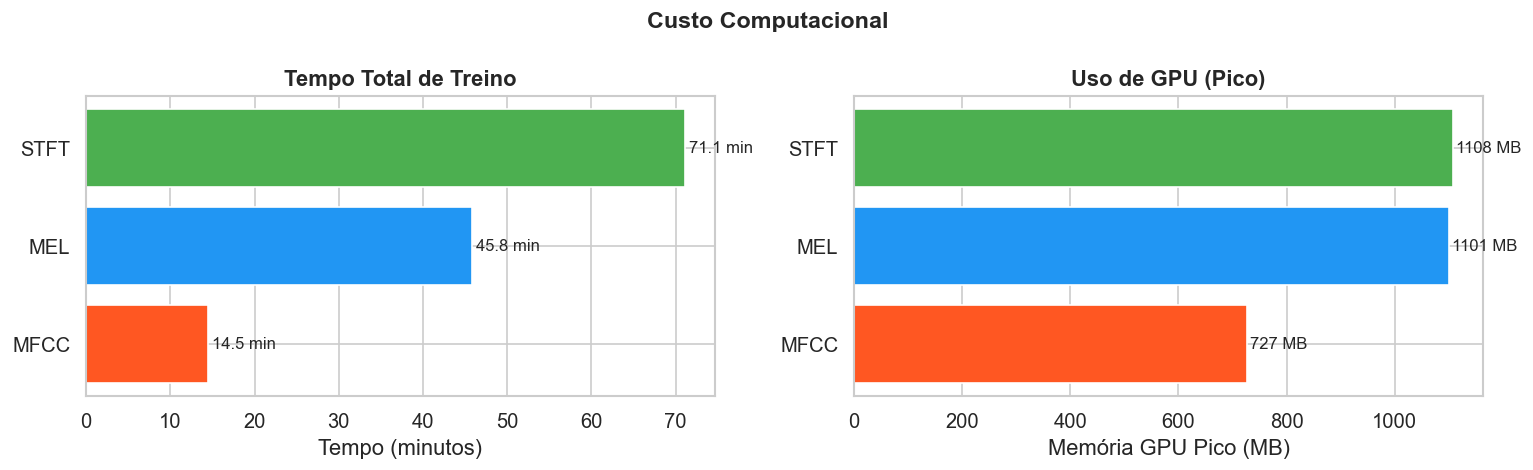

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sub = df.sort_values('Tempo (min)', ascending=True); cores = [cores_modo[m] for m in sub['Modo']]
bars = axes[0].barh(sub['Modo'], sub['Tempo (min)'], color=cores, edgecolor='white')
axes[0].set_xlabel('Tempo (minutos)'); axes[0].set_title('Tempo Total de Treino', fontweight='bold')
for bar, v in zip(bars, sub['Tempo (min)']):
    axes[0].text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f} min', va='center', fontsize=10)
bars2 = axes[1].barh(sub['Modo'], sub['GPU Pico (MB)'], color=cores, edgecolor='white')
axes[1].set_xlabel('Memória GPU Pico (MB)'); axes[1].set_title('Uso de GPU (Pico)', fontweight='bold')
for bar, v in zip(bars2, sub['GPU Pico (MB)']):
    axes[1].text(v+5, bar.get_y()+bar.get_height()/2, f'{v:.0f} MB', va='center', fontsize=10)
plt.suptitle('Custo Computacional', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Tradeoff: Performance × Custo Computacional

Cada bolha representa um modelo. O eixo X é o tempo de treino, o Y é a performance média (Pearson de Arousal e Valence), e o **tamanho da bolha** representa o pico de uso de memória GPU.

O modelo ideal fica no **canto superior esquerdo**: máxima performance com menor custo. Modelos próximos entre si em Y mas distantes em X têm performance equivalente com custo diferente — o mais rápido é preferível nesse caso.

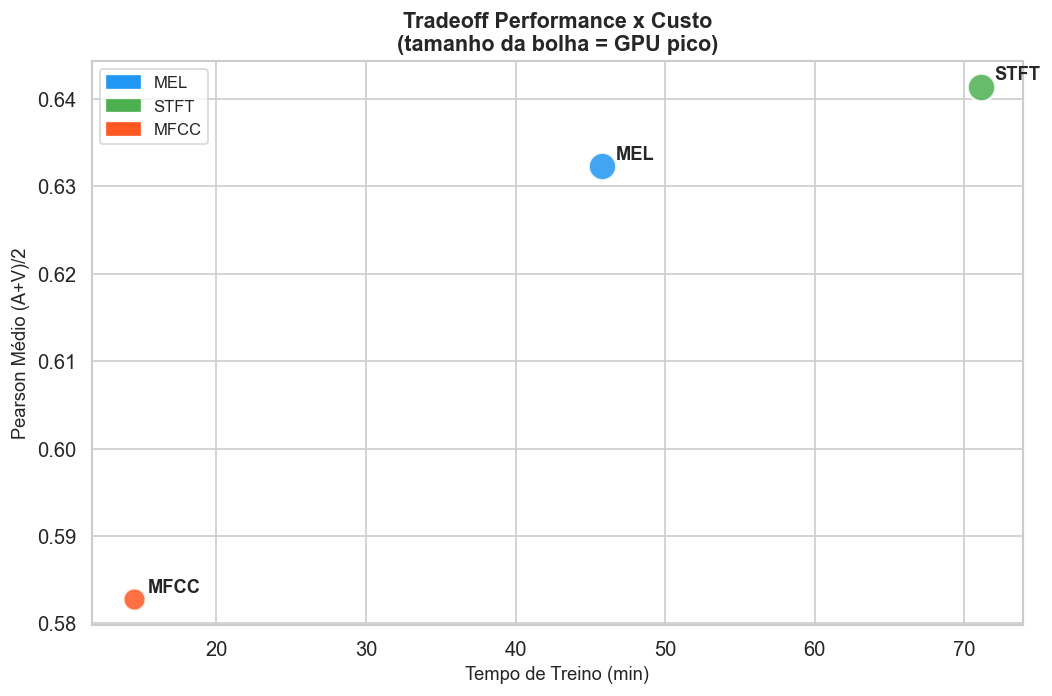

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df.iterrows():
    score_av = (row['Pearson A']+row['Pearson V'])/2; cor = cores_modo[row['Modo']]
    ax.scatter(row['Tempo (min)'], score_av, s=row['GPU Pico (MB)']/4,
               c=cor, alpha=0.85, edgecolors='white', linewidths=1.5)
    ax.annotate(row['Modo'], (row['Tempo (min)'], score_av),
                textcoords='offset points', xytext=(8,4), fontsize=11, fontweight='bold')
ax.set_xlabel('Tempo de Treino (min)', fontsize=11); ax.set_ylabel('Pearson Médio (A+V)/2', fontsize=11)
ax.set_title('Tradeoff Performance x Custo\n(tamanho da bolha = GPU pico)', fontsize=13, fontweight='bold')
handles = [mpatches.Patch(color=c, label=m) for m, c in cores_modo.items()]
ax.legend(handles=handles, fontsize=10); plt.tight_layout(); plt.show()


## 9. Ranking Final

Classificação dos modelos por **Pearson médio (Arousal + Valence) / 2** — métrica de referência que equilibra o desempenho nas duas dimensões emocionais. O CCC médio é apresentado como métrica secundária (mais rigorosa).

**Interpretação dos resultados:**
- A diferença entre MEL e STFT é pequena — teste de Wilcoxon nos 5 folds confirma que não é estatisticamente significativa (p > 0.05), o que é honesto e esperado com apenas 5 amostras por fold
- O MFCC ficou consistentemente abaixo: a compressão para apenas 13 coeficientes descarta informação espectral importante para prever emoção
- O baixo desempenho em **Valence** é um problema conhecido na literatura de MER: valence tem correlação fraca com features acústicas de baixo nível, dependendo mais de harmonia e contexto musical

In [ ]:
df_rank = df.copy()
df_rank['Score AV'] = (df_rank['Pearson A']+df_rank['Pearson V'])/2
df_rank['CCC AV']   = (df_rank['CCC A']+df_rank['CCC V'])/2
df_rank = df_rank.sort_values('Score AV', ascending=False).reset_index(drop=True)
df_rank.index += 1
print('='*60)
print(f'{"#":>2}  {"Modo":<8} {"Pearson AV":>10} {"CCC AV":>8} {"F1-macro":>9} {"Tempo":>8}')
print('='*60)
for idx, row in df_rank.iterrows():
    flag = ' <- MELHOR' if idx==1 else (' <- PIOR' if idx==len(df_rank) else '')
    print(f'{idx:>2}  {row["Modo"]:<8} {row["Score AV"]:>10.4f} {row["CCC AV"]:>8.4f} {row["F1-macro Q"]:>9.4f} {row["Tempo (min)"]:>7.1f}m{flag}')
melhor = df_rank.iloc[0]
print(f'\nMelhor: {melhor["Modo"]}')
print(f'  Pearson A={melhor["Pearson A"]:.4f}  V={melhor["Pearson V"]:.4f}')
print(f'  CCC     A={melhor["CCC A"]:.4f}  V={melhor["CCC V"]:.4f}')
print(f'  F1-macro: {melhor["F1-macro Q"]:.4f}  |  Tempo: {melhor["Tempo (min)"]:.1f} min')


 #  Modo     Pearson AV   CCC AV  F1-macro    Tempo
 1  STFT         0.6414   0.6368    0.4574    71.1m <- MELHOR
 2  MEL          0.6323   0.6276    0.4538    45.8m
 3  MFCC         0.5828   0.5753    0.4440    14.5m <- PIOR

Melhor: STFT
  Pearson A=0.7781  V=0.5047
  CCC     A=0.7701  V=0.5036
  F1-macro: 0.4574  |  Tempo: 71.1 min


## 10. Distribuição do CCC por Fold — Validação Cruzada (5-fold)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

MODOS  = ['STFT', 'MEL', 'MFCC']
CORES  = {'STFT': '#4CAF50', 'MEL': '#2196F3', 'MFCC': '#FF5722'}

cv_data = {
    nome.split('_')[1].upper(): r['cv_metricas']
    for nome, r in resultados.items()
}

fig, (ax_a, ax_v) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('CCC na Validação Cruzada (5-fold) — Média ± Desvio Padrão',
             fontsize=13, fontweight='bold')

x = np.arange(len(MODOS))
w = 0.5

for ax, chave, titulo in [(ax_a, 'ccc_a', 'CCC — Arousal'), (ax_v, 'ccc_v', 'CCC — Valence')]:
    medias = [cv_data[m][chave]['media'] for m in MODOS]
    stds   = [cv_data[m][chave]['std']   for m in MODOS]
    cores  = [CORES[m] for m in MODOS]

    bars = ax.bar(x, medias, w, color=cores, edgecolor='white',
                  yerr=stds, capsize=8,
                  error_kw=dict(elinewidth=2, ecolor='#333333', capthick=2))

    for bar, m, s in zip(bars, medias, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.008,
                f'{m:.4f}\n±{s:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold', linespacing=1.4)

    ax.set_xticks(x)
    ax.set_xticklabels(MODOS, fontweight='bold', fontsize=12)
    ax.set_ylabel('CCC (média ± std nos 5 folds)', fontsize=10)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    lim_sup = max(m + s for m, s in zip(medias, stds))
    ax.set_ylim(0, min(1.0, lim_sup + 0.10))
    ax.axhline(0.65, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='Ref. 0.65')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
os.makedirs('figuras_tcc', exist_ok=True)
plt.savefig('figuras_tcc/fig_cv_wilcoxon_5_5.png', dpi=200, bbox_inches='tight')
plt.show()
print("Salvo em: figuras_tcc/fig_cv_wilcoxon_5_5.png")

## 11. O Problema de Valence — Assimetria de Desempenho

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

MODOS = ['STFT', 'MEL', 'MFCC']
CORES = {'STFT': '#4CAF50', 'MEL': '#2196F3', 'MFCC': '#FF5722'}

dados = {
    nome.split('_')[1].upper(): r
    for nome, r in resultados.items()
}

ccc_a = [dados[m]['test_ccc_arousal'] for m in MODOS]
ccc_v = [dados[m]['test_ccc_valence'] for m in MODOS]
r2_a  = [dados[m]['test_r2_arousal']  for m in MODOS]
r2_v  = [dados[m]['test_r2_valence']  for m in MODOS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('O Problema de Valence — Assimetria de Desempenho por Representação Espectral',
             fontsize=13, fontweight='bold')

x   = np.arange(len(MODOS))
w   = 0.32
gap = w + 0.04

# ── Painel 1: CCC ────────────────────────────────────────────────────────────
bars_a = ax1.bar(x - w/2, ccc_a, w, color=[CORES[m] for m in MODOS],
                 edgecolor='white', label='Arousal', alpha=1.0)
bars_v = ax1.bar(x + w/2, ccc_v, w, color=[CORES[m] for m in MODOS],
                 edgecolor='white', label='Valence', alpha=0.45, hatch='//')

# Rótulos de valor
for bar, v in zip(bars_a, ccc_a):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.008,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(bars_v, ccc_v):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.008,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, color='#444')

# Seta de gap para cada modelo
for i, (va, vv, modo) in enumerate(zip(ccc_a, ccc_v, MODOS)):
    mid_x = i
    ax1.annotate('', xy=(mid_x + w/2, vv + 0.002),
                 xytext=(mid_x - w/2, va - 0.002),
                 arrowprops=dict(arrowstyle='<->', color='#c62828', lw=1.5))
    ax1.text(mid_x + w/2 + 0.04, (va + vv)/2,
             f'Δ={va - vv:.3f}', fontsize=8, color='#c62828', va='center', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(MODOS, fontweight='bold', fontsize=11)
ax1.set_ylabel('CCC', fontsize=11)
ax1.set_title('CCC — Arousal vs Valence', fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor='#888', label='Arousal (sólido)'),
    mpatches.Patch(facecolor='#bbb', hatch='//', label='Valence (hachura)'),
]
ax1.legend(handles=legend_handles, fontsize=9, loc='lower right')

# ── Painel 2: R² ─────────────────────────────────────────────────────────────
bars_ra = ax2.bar(x - w/2, r2_a, w, color=[CORES[m] for m in MODOS],
                  edgecolor='white', label='Arousal', alpha=1.0)
bars_rv = ax2.bar(x + w/2, r2_v, w, color=[CORES[m] for m in MODOS],
                  edgecolor='white', label='Valence', alpha=0.45, hatch='//')

for bar, v in zip(bars_ra, r2_a):
    offset = 0.015 if v >= 0 else -0.04
    ax2.text(bar.get_x() + bar.get_width()/2, v + offset,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(bars_rv, r2_v):
    offset = 0.015 if v >= 0 else -0.04
    ax2.text(bar.get_x() + bar.get_width()/2, v + offset,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, color='#444')

ax2.axhline(0, color='#c62828', linewidth=1.5, linestyle='--', alpha=0.8, label='R² = 0')
ax2.set_xticks(x)
ax2.set_xticklabels(MODOS, fontweight='bold', fontsize=11)
ax2.set_ylabel('R²', fontsize=11)
ax2.set_title('R² — Arousal vs Valence', fontweight='bold')
y_min = min(r2_v) - 0.06
ax2.set_ylim(y_min, max(r2_a) + 0.12)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(handles=legend_handles + [
    mpatches.Patch(facecolor='#c62828', label='R² = 0 (baseline ingênuo)')
], fontsize=9, loc='upper right')

# Anotação MFCC R² negativo
mfcc_rv = r2_v[MODOS.index('MFCC')]
ax2.annotate('R² < 0\n(pior que\nbaseline)',
             xy=(MODOS.index('MFCC') + w/2, mfcc_rv),
             xytext=(MODOS.index('MFCC') + w/2 + 0.45, mfcc_rv - 0.06),
             fontsize=8, color='#c62828', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#c62828', lw=1.2))

plt.tight_layout()
os.makedirs('figuras_tcc', exist_ok=True)
plt.savefig('figuras_tcc/fig_valence_problem_5_6.png', dpi=200, bbox_inches='tight')
plt.show()
print("Salvo em: figuras_tcc/fig_valence_problem_5_6.png")